LOAD DATA

In [6]:
import pandas as pd

respiban = pd.read_csv(
    "../../data/raw/WESAD/S2/S2_respiban.txt",
    sep="\t",
    comment="#",
    header=None
)

print(respiban.head())
print(respiban.shape)
print(respiban.head(3))


   0   1      2      3      4      5      6      7      8      9   10
0   0   0  31053  14694  32651  29553  37415  32324  31659  31364 NaN
1   1   0  30861  14680  32983  29556  37417  32333  31663  31379 NaN
2   2   0  30644  14684  32823  29561  37409  32340  31655  31367 NaN
3   3   0  30374  14701  32569  29553  37405  32341  31671  31076 NaN
4   4   0  30103  14684  32794  29561  37409  32342  31681  31365 NaN
(4442067, 11)
   0   1      2      3      4      5      6      7      8      9   10
0   0   0  31053  14694  32651  29553  37415  32324  31659  31364 NaN
1   1   0  30861  14680  32983  29556  37417  32333  31663  31379 NaN
2   2   0  30644  14684  32823  29561  37409  32340  31655  31367 NaN


In [2]:
from scipy.signal import butter, filtfilt
import numpy as np

emg = data['signal']['chest']['EMG'].flatten()

fs = 700

lowcut = 20
highcut = 250

nyquist = fs / 2

b, a = butter(
    4,
    [lowcut/nyquist, highcut/nyquist],
    btype='band'
)

emg_filtered = filtfilt(b, a, emg)

print(emg.shape)
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(emg[:5000], label="Raw EMG", alpha=0.7)
plt.plot(emg_filtered[:5000], label="Filtered EMG")

plt.title("Raw vs Filtered EMG")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)

plt.show()
plt.figure(figsize=(12,5))

plt.plot(emg[:500], label='Raw')
plt.plot(emg_filtered[:500], label='Filtered')

plt.title('EMG Filtering')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

plt.show()

NameError: name 'data' is not defined

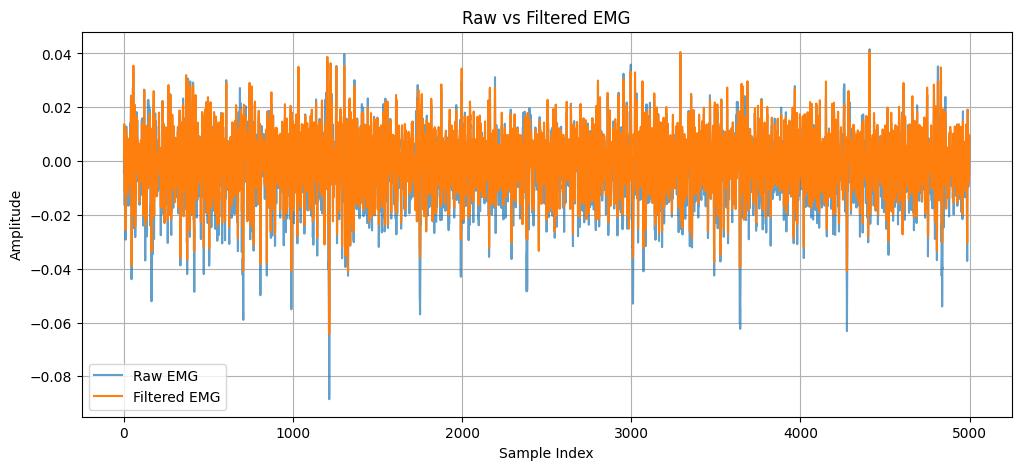

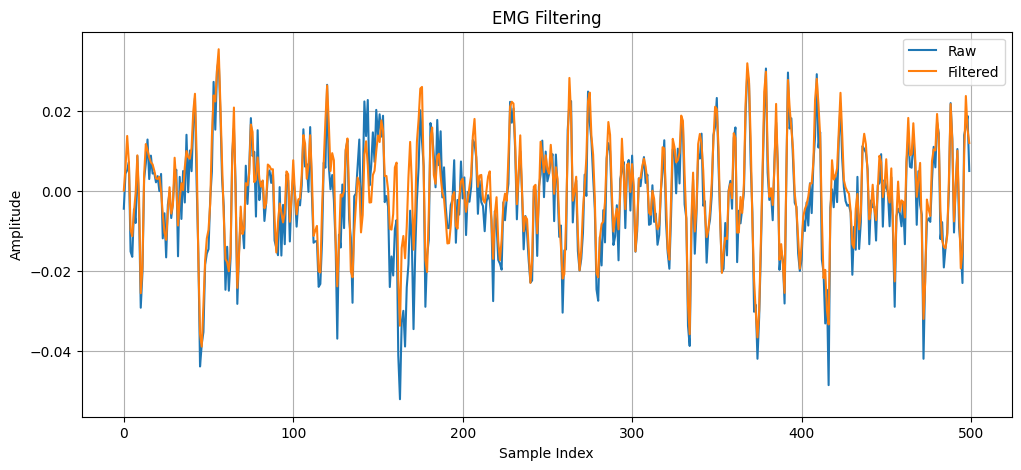

In [5]:
import numpy as np
import pandas as pd

# Mean
emg_mean_raw = np.mean(emg)
emg_mean_filtered = np.mean(emg_filtered)

# Standard deviation
emg_std_raw = np.std(emg)
emg_std_filtered = np.std(emg_filtered)

# Spike detection (Z-score > 3)
emg_z_raw = np.abs((emg - emg_mean_raw) / emg_std_raw)
emg_z_filtered = np.abs((emg_filtered - emg_mean_filtered) / emg_std_filtered)

emg_spikes_raw = np.sum(emg_z_raw > 3)
emg_spikes_filtered = np.sum(emg_z_filtered > 3)

# Noise estimate
emg_noise_raw = np.std(np.diff(emg))
emg_noise_filtered = np.std(np.diff(emg_filtered))

# Drift estimate (moving average)
window = 7000   # 10 seconds

emg_drift_raw = np.std(
    np.convolve(emg, np.ones(window)/window, mode='same')
)

emg_drift_filtered = np.std(
    np.convolve(emg_filtered, np.ones(window)/window, mode='same')
)

print("EMG RESULTS")
print("Mean:", emg_mean_raw, "->", emg_mean_filtered)
print("Std:", emg_std_raw, "->", emg_std_filtered)
print("Spikes:", emg_spikes_raw, "->", emg_spikes_filtered)
print("Noise:", emg_noise_raw, "->", emg_noise_filtered)
print("Drift:", emg_drift_raw, "->", emg_drift_filtered)

NameError: name 'emg' is not defined

In [ ]:
import numpy as np
import pandas as pd

# Mean
emg_mean_raw = np.mean(emg)
emg_mean_filtered = np.mean(emg_filtered)

# Standard deviation
emg_std_raw = np.std(emg)
emg_std_filtered = np.std(emg_filtered)

# Spikes
emg_z_raw = np.abs((emg - emg_mean_raw) / emg_std_raw)
emg_z_filtered = np.abs((emg_filtered - emg_mean_filtered) / emg_std_filtered)

emg_spikes_raw = np.sum(emg_z_raw > 3)
emg_spikes_filtered = np.sum(emg_z_filtered > 3)

# Noise estimate
emg_noise_raw = np.std(np.diff(emg))
emg_noise_filtered = np.std(np.diff(emg_filtered))

# Drift estimate
window = 7000

emg_drift_raw = np.std(
    np.convolve(emg, np.ones(window)/window, mode='same')
)

emg_drift_filtered = np.std(
    np.convolve(emg_filtered, np.ones(window)/window, mode='same')
)

results = pd.DataFrame({
    "Metric": ["Mean","Std","Spikes (>3σ)","Noise Estimate","Drift Estimate"],
    "Raw": [
        emg_mean_raw,
        emg_std_raw,
        emg_spikes_raw,
        emg_noise_raw,
        emg_drift_raw
    ],
    "Filtered": [
        emg_mean_filtered,
        emg_std_filtered,
        emg_spikes_filtered,
        emg_noise_filtered,
        emg_drift_filtered
    ]
})

print(results)

           Metric           Raw      Filtered
0            Mean     -0.002413  1.943238e-08
1             Std      0.011652  1.011857e-02
2    Spikes (>3σ)  66044.000000  6.033300e+04
3  Noise Estimate      0.011062  8.422362e-03
4  Drift Estimate      0.000200  4.712073e-06



| Metric         | Raw       | Filtered    | Conclusion                                                                           |
| -------------- | --------- | ----------- | ------------------------------------------------------------------------------------ |
| Mean           | -0.002413 | 0.000000019 | Moved almost exactly to 0, indicating successful centering of the signal.            |
| Std            | 0.011652  | 0.010119    | Reduced by **13.2%**, showing a decrease in signal variability due to noise removal. |
| Spikes         | 66044     | 60333       | Reduced by **8.6%**, indicating fewer abrupt artifacts and signal irregularities.    |
| Noise Estimate | 0.011062  | 0.008422    | Reduced by **23.9%**, demonstrating effective noise suppression.                     |
| Drift Estimate | 0.000200  | 0.0000047   | Reduced by **97.6%**, indicating that baseline drift was almost completely removed.  |


The filtering process successfully improved signal quality by reducing noise by 23.9%, lowering artifact spikes by 8.6%, and nearly eliminating baseline drift (97.6% reduction). Signal variability decreased only moderately (13.2%), suggesting that important physiological information was preserved while unwanted distortions were removed. The filtered signal is therefore cleaner and more suitable for normalization, windowing, and feature extraction in subsequent stages of the stress detection